# Bitcoin price forecast with LSTM
https://en.wikipedia.org/wiki/Long_short-term_memory

In [472]:
import math
import yfinance as yf
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input
from tensorflow.keras.optimizers import Adam
from datetime import datetime, timedelta

## Load Bitcoin Prices

In [473]:
df = yf.download('BTC-USD', start='2017-01-01', end='2025-05-10')
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008
2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992
2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000
2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984
2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008
...,...,...,...,...,...
2025-05-05,94748.054688,95193.187500,93566.265625,94319.562500,25816260327
2025-05-06,96802.476562,96889.179688,93399.859375,94748.382812,26551275827


In [474]:
df_close = df[('Close', 'BTC-USD')].to_frame(name='Close')
df_close

,Close
Date,
2017-01-01,998.325012
2017-01-02,1021.750000
2017-01-03,1043.839966
2017-01-04,1154.729980
2017-01-05,1013.380005
...,...
2025-05-05,94748.054688
2025-05-06,96802.476562
2025-05-07,97032.320312


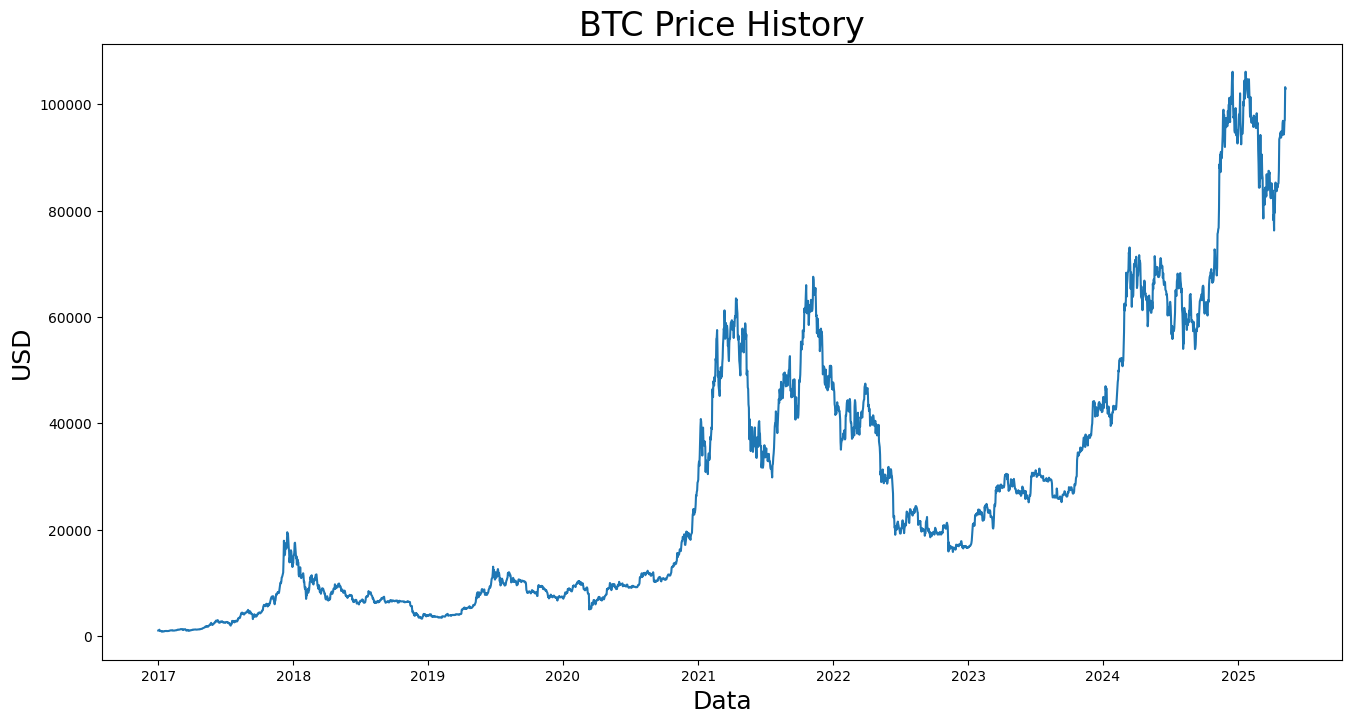

In [475]:
plt.figure(figsize=(16,8))
plt.title('BTC Price History', fontsize=24)
plt.plot(df_close['Close'])
plt.xlabel('Data', fontsize=18)
plt.ylabel('USD', fontsize=18)
plt.show()

## Prepare data

In [476]:
# Number of days to look back
lookback = 30

# Create a DF with only close price
data = df_close.filter(['Close'])

# Convert the dataframe to numpy array
dataset = data.values

# Reserve 80% to train
training_data_len = math.ceil(len(dataset) * .8) # We are using %80 of the data for training
training_data_len

# Scale the data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

# Training dataset
train_data = scaled_data[0:training_data_len, :]

# Split the data into X_train and y_train data sets
X_train = []
y_train = []

for i in range(lookback, len(train_data)):
  X_train.append(train_data[i-lookback: i, 0])
  y_train.append(train_data[i, 0])

# Convert the X_train and y_train to numpy array
X_train, y_train = np.array(X_train), np.array(y_train)


# Reshape the data for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_train.shape

# Create the testing dataset
test_data = scaled_data[training_data_len - lookback : , :]

# Create the dataset X_test and y_test
X_test = []
y_test = dataset[training_data_len : , :]
for i in range(lookback, len(test_data)):
  X_test.append(test_data[i-lookback : i, 0])


# Convert the data to a numpy array 
X_test = np.array(X_test)

# Reshape the test data
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

## Build LSTM Model

In [ ]:
# Build LSTM model
tf.random.set_seed(42)

patience = 20
epochs = 25
min_improvement = 0.1

model = Sequential([
  Input(shape=(X_train.shape[1], 1)),
  LSTM(50, activation='tanh', return_sequences=True),
  LSTM(50, activation='tanh', return_sequences=False),
  Dense(25),
  Dense(1)
])

optimizer = Adam(learning_rate=0.0027)

# Compile the model
model.compile(optimizer, loss='mse')

model.summary()


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_72 (LSTM)                  │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_73 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [478]:
# Train the model
callback = tf.keras.callbacks.EarlyStopping(
  monitor='loss',
  patience=patience,
  restore_best_weights=True,
  min_delta=min_improvement
)
history = model.fit(X_train, y_train, batch_size=1, epochs=epochs, callbacks=[callback])

Epoch 1/25
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0019
Epoch 2/25
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 4.1338e-04
Epoch 3/25
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 3.2497e-04
Epoch 4/25
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 2.6647e-04
Epoch 5/25
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 2.2644e-04
Epoch 6/25
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 2.1369e-04
Epoch 7/25
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 2.0567e-04
Epoch 8/25
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 2.0096e-04
Epoch 9/25
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 1.9301e-04
Epoch 10/25
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 1.8812e-04
Epoch 11/25
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 1.8351e-04
Epoch 12/25
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 1.7952e-04
Epoch 13/25
2411/2411 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 1.7570e-04
Epoch 14/25
2411/2411 ━━━━━━━━━━━━━━━━

## Epochs vs Loss

Text(0.5, 0, 'Epochs')

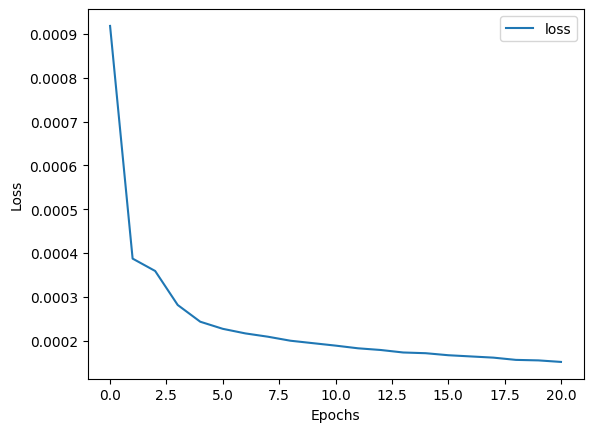

In [479]:
historyPlot = pd.DataFrame(history.history)
historyPlot.plot()
plt.ylabel("Loss")
plt.xlabel("Epochs")

## Compare real price with predicted price

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


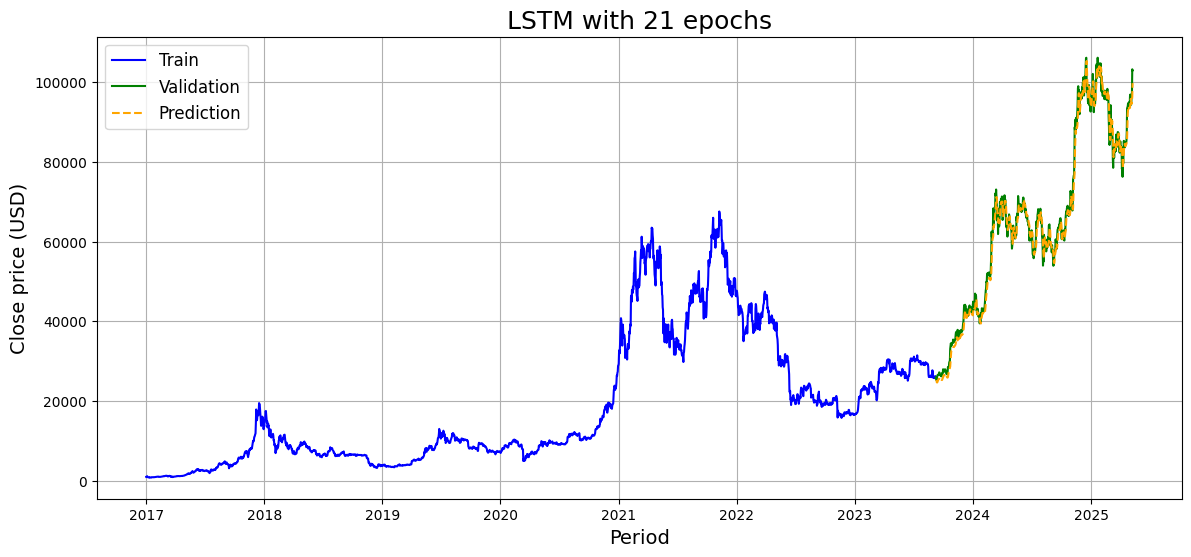

In [480]:
# Predictions values
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Split data into train and validation
train = data[:training_data_len].copy()
valid = data[training_data_len:].copy()

# Add prediction to validation dataframe
valid['Predictions'] = predictions

# Plotar os dados
plt.figure(figsize=(14, 6))
plt.title(f'LSTM with {len(history.history["loss"])} epochs', fontsize=18)
plt.xlabel('Period', fontsize=14)
plt.ylabel('Close price (USD)', fontsize=14)
plt.plot(train['Close'], label='Train', color='blue')
plt.plot(valid['Close'], label='Validation', color='green')
plt.plot(valid['Predictions'], label='Prediction', color='orange', linestyle='--')
plt.legend(['Train', 'Validation', 'Prediction'], loc='upper left', fontsize=12)
plt.grid(True)
plt.show()

## Predicted price for the next 10 days

In [ ]:
# Number of days to predict
future_days = 5

print("Shape of last_30_days:", last_30_days.shape)  # Should be (30, 1)

# Scale the data using the same scaler used for training
last_30_days_scaled = scaler.transform(last_30_days)
print("Shape of last_30_days_scaled:", last_30_days_scaled.shape)  # Should be (30, 1)

# List to store scaled predictions
future_predictions_scaled = []

# Initial array with the last 30 days scaled
current_input = last_30_days_scaled
print("Initial shape of current_input:", current_input.shape)  # Should be (30, 1)

# Generate predictions for the next 7 days
for i in range(future_days):
  # Reshape to the format expected by the model (1, 30, 1)
  current_input_reshaped = np.reshape(current_input, (1, current_input.shape[0], 1))

  # Predict the next day
  next_pred_scaled = model.predict(current_input_reshaped, verbose=0)

  # Store the prediction
  future_predictions_scaled.append(next_pred_scaled[0, 0])

  # Update the input window: remove the oldest day and add the prediction
  next_pred_scaled = next_pred_scaled.reshape(1, 1)  # Ensure shape is (1, 1)
  current_input = np.append(current_input[1:], next_pred_scaled, axis=0)

# Convert scaled predictions back to real prices
future_predictions = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

# Use today's date as the starting point
today = datetime.now()  # Today's date: May 12, 2025

# Create future dates starting from today
future_dates = [today + timedelta(days=i) for i in range(future_days)]

# Create a DataFrame with dates and predicted prices
future_df = pd.DataFrame({
  'Date': future_dates,
  'Predicted Value': future_predictions.flatten()
})
future_df.set_index('Date', inplace=True)

# Display predictions in a more readable format
print("\nBitcoin price predictions for the next days:")
for date, price in zip(future_dates, future_predictions.flatten()):
  formatted_date = date.strftime('%Y-%m-%d')
  print(f"Date: {formatted_date} - Predicted Price: ${price:.2f}")

Shape of last_30_days: (30, 1)
Shape of last_30_days_scaled: (30, 1)
Initial shape of current_input: (30, 1)

Bitcoin price predictions for the next days:
Date: 2025-05-12 - Predicted Price: $101781.88
Date: 2025-05-13 - Predicted Price: $101921.07
Date: 2025-05-14 - Predicted Price: $101660.60
Date: 2025-05-15 - Predicted Price: $101274.57
Date: 2025-05-16 - Predicted Price: $100871.33
